
## **Business Context & Objectives**

#### The company operates a global e-commerce platform selling products across categories including sporting goods, fitness equipment, outdoor gear, footwear, and apparel across multiple international regions.


## **Core Business Problem**

#### Actual shipping times frequently deviate from scheduled delivery windows, creating eroded customer trust, reduced order profitability, and an inability to make reliable commitments to buyers at point of purchase.



## **Analytical Objectives**

- Understand the current state of delivery performance across all dimensions (region, mode, time, segment)

- Quantify the financial impact of delays on order profitability
- Identify the primary operational bottlenecks driving late deliveries
- Build a predictive model to flag high-risk orders before they are shipped
- Deliver actionable recommendations to improve on-time delivery and profitability


## Business Problem
#### A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

## Desired Outcome:
#### The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')


In [2]:

# Custom Professional Palette
modern_palette = ['#1A5276', '#117A65', '#F39C12', '#CB4335', '#566573']

sns.set_palette(modern_palette)

primary_color   = modern_palette[0] # Professional Dark Blue
secondary_color = modern_palette[1] # Deep Teal
accent_color    = modern_palette[2] # Alert Orange/Gold
danger_color    = modern_palette[3] # Modern Muted Red
neutral_color   = modern_palette[4] # Balanced Grey

In [3]:
df = pd.read_csv('/DataCoSupplyChainDataset.csv', encoding = 'latin-1')

In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.shape

(180519, 53)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

### **Exploratory Data Analysis (EDA)**

In [8]:
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns)
print('\nNum Duplicates:', df.duplicated().sum())
print('\nMissing Values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))


rows, cols: (180519, 53)

columns:
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Produ

In [9]:
df.head().T

,0,1,2,3,4
Type,DEBIT,TRANSFER,CASH,DEBIT,PAYMENT
Days for shipping (real),3,5,4,3,2
Days for shipment (scheduled),4,4,4,4,4
Benefit per order,91.25,-249.089996,-247.779999,22.860001,134.210007
Sales per customer,314.640015,311.359985,309.720001,304.809998,298.25
Delivery Status,Advance shipping,Late delivery,Shipping on time,Advance shipping,Advance shipping
Late_delivery_risk,0,1,0,0,0
Category Id,73,73,73,73,73
Category Name,Sporting Goods,Sporting Goods,Sporting Goods,Sporting Goods,Sporting Goods
Customer City,Caguas,Caguas,San Jose,Los Angeles,Caguas


In [10]:
df['Delivery Status'].unique()

array(['Advance shipping', 'Late delivery', 'Shipping on time',
       'Shipping canceled'], dtype=object)

In [11]:
(df['Benefit per order'] == df['Order Profit Per Order' ]).value_counts()

,count
True,180519


In [12]:
df['Product Status'].value_counts()

,count
Product Status,
0,180519


In [13]:
df.shape

(180519, 53)

In [14]:
df.columns = df.columns.str.strip()

In [15]:
# Data cleaning
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Latitude',
    'Longitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',  # Identical to Order Profit Per Order
    'Product Status',  # have only one value
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# Dropping the columns that are either fully missing, redundant or have only one value
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Removing canceled orders since they are not relevant for delivery time analysis
df = df[df['Delivery Status'] != 'Shipping canceled']


In [16]:
# standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors= 'coerce', dayfirst = False)


In [17]:
# checking the data overview again after cleaning
print('rows, cols:', df.shape)
print('\n\n\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)



Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [18]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [19]:
# Value counts for categorical columns with low cardinality

for col in df.columns:
  if df[col].nunique() < 10:
    print(f'\n{col} value counts:')
    print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [20]:
# calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] >0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['Order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [21]:
df['Is_Delayed'].value_counts()

,count
Is_Delayed,
True,94523
False,78242


In [22]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'Order_day', 'order_hour'],
      dtype='object')

In [23]:
df['Order Profit Per Order']

,Order Profit Per Order
0,91.250000
1,-249.089996
2,-247.779999
3,22.860001
4,134.210007
...,...
180514,40.000000
180515,-613.770019
180516,141.110001
180517,186.229996


In [24]:
# Profitability Flag based on Order Profit Per Order
df['Profitability_Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit',
                                    np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Profitability_Flag'].value_counts()

,count
Profitability_Flag,
Profit,139354
Loss,32295
Break-even,1116


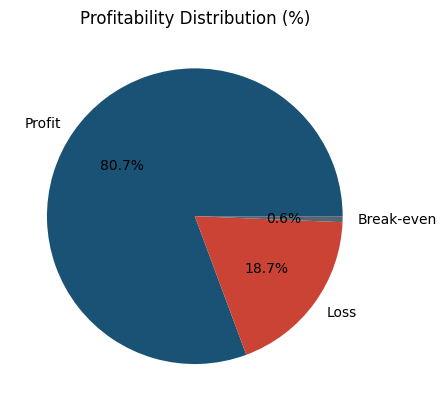

In [25]:
# visualization of profitability distribution

profit_counts = df['Profitability_Flag'].value_counts(normalize = True) * 100
profit_counts.plot(kind ='pie', autopct = '%1.1f%%',
                   colors = [primary_color, danger_color, neutral_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()


In [26]:
df[df['Order Profit Per Order'] < 0]['Order Profit Per Order'].sum()

np.float64(-3708393.175825706)

In [27]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = (float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100


metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n— Business KPIs —\n')
for k, v in metrics.items():
    if isinstance(v, (float, np.float64)):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


— Business KPIs —

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


### **Profitability vs Delivery Time Analysis**

In [28]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count').reset_index()
)
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [29]:
delay_distribution = (
    df['Delay'].value_counts(normalize = True).sort_index() * 100).reset_index()

delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


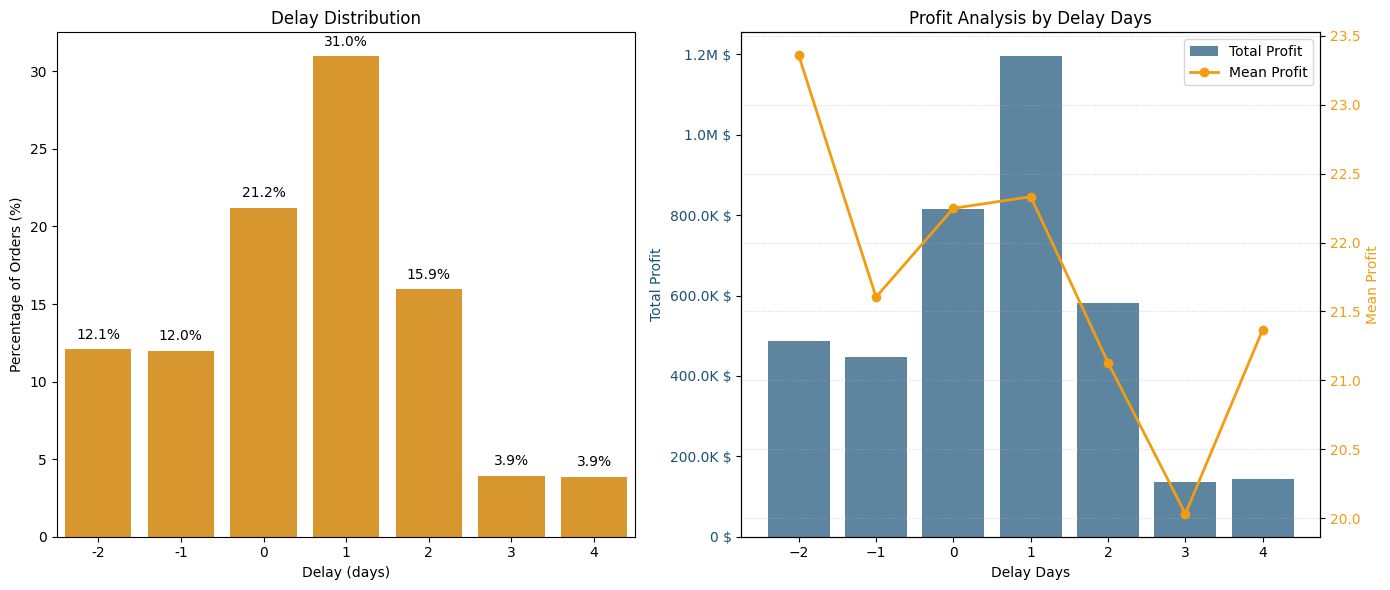

In [30]:

# Clean the Column Names
delay_distribution.columns = ['Delay Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))
print("\nDelay Distribution (%):")
display(delay_distribution)

# Figure Setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- FIRST SUBPLOT: Delay Distribution ---
sns.barplot(x='Delay Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of Orders (%)')

# Adding percentage text on top of bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha="center", va='bottom')

# --- SECOND SUBPLOT: Profit Analysis by Delay Days ---
# Primary Y-Axis (Bar Chart for Total Profit)
ax2.set_xlabel("Delay Days")
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, alpha=0.7, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

# Create a second Y-Axis for Mean Profit (Line Chart)
ax3 = ax2.twinx()
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color, linewidth=2)
ax3.tick_params(axis='y', labelcolor=accent_color)

# 3. Formatting the Currency (1e6 and 1e3 logic)
def format_func(value, tick_number):
    if abs(value) >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif abs(value) >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

# 4. Final Touches
ax3.set_title("Profit Analysis by Delay Days")

# Merging legends from both axes
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc="upper right")

ax3.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### **Bottlenect Detection**

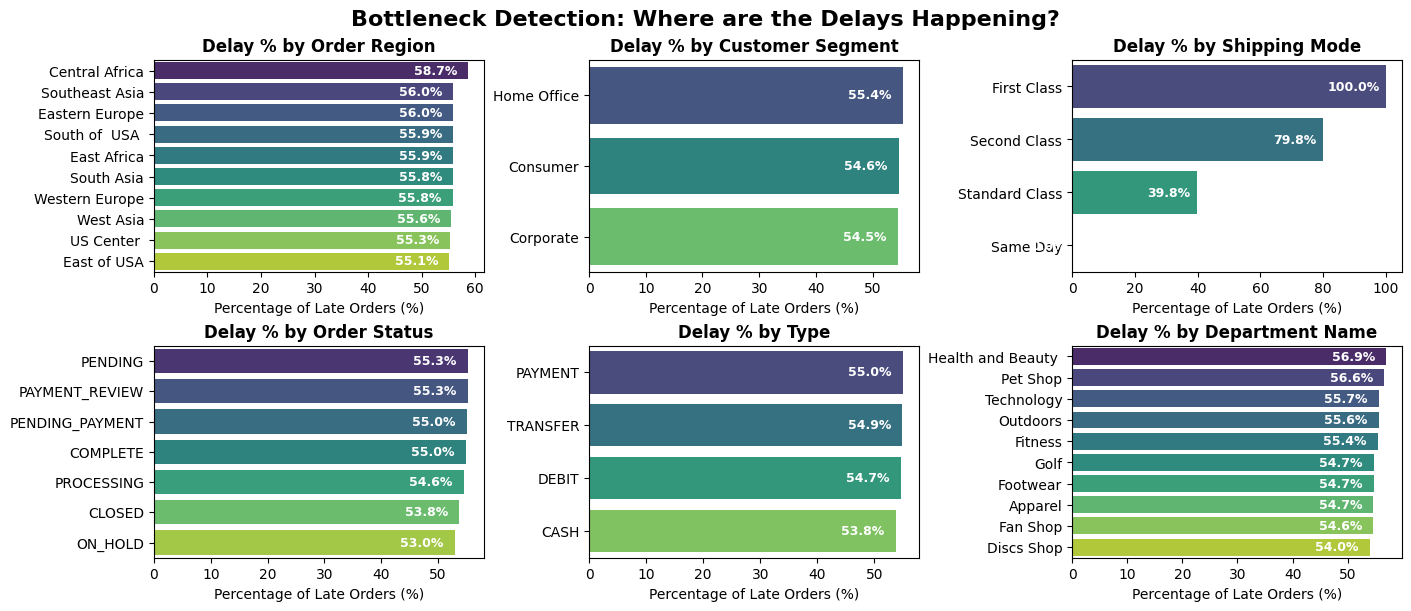

In [31]:

def compute_delay_pct_by_category(category):
    # Aggregating count and sum of delays
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')).reset_index()

    # Calculating the percentage
    cat_df['delay_pct'] = (cat_df['late_orders'] / cat_df['total_orders']) * 100

    # Sorting to show the worst offenders at the top
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

# List of categories to check
categories = ['Order Region', 'Customer Segment', 'Shipping Mode',
              'Order Status', 'Type', 'Department Name']

# Creating the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(14, 6), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    # Drawing the bar plot
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'    )

    # Styling the subplot
    ax.set_title(f'Delay % by {category}', fontweight='bold')
    ax.set_xlabel('Percentage of Late Orders (%)')
    ax.set_ylabel('') # Cleared for better visibility

    # Adding the text labels inside the bars
    for i, row in enumerate(cat_df.itertuples()):
        # Placing the text slightly inside the bar (hence the -2)
        ax.text(row.delay_pct - 2, i, f'{row.delay_pct:.1f}%',
                va='center', ha='right', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Bottleneck Detection: Where are the Delays Happening?', fontsize=16, fontweight='bold')
plt.show()

### **Root Cause Analysis**

In [32]:
# Grouping by Shipping Mode to see the 'Gap'
ship_mode_analysis = df.groupby('Shipping Mode').agg(
    Avg_Scheduled=('Days for shipment (scheduled)', 'mean'),
    Avg_Real=('Days for shipping (real)', 'mean'),
    Avg_Delay_Days=('Delay', 'mean'),
    Late_Pct=('Is_Delayed', 'mean')
).reset_index()

# Convert Late_Pct to a readable percentage
ship_mode_analysis['Late_Pct'] = (ship_mode_analysis['Late_Pct'] * 100).round(1)

display(ship_mode_analysis)

,Shipping Mode,Avg_Scheduled,Avg_Real,Avg_Delay_Days,Late_Pct
0,First Class,1.0,2.000000,1.000000,100.0
1,Same Day,0.0,0.479285,0.000000,0.0
2,Second Class,2.0,3.993167,1.993167,79.8
3,Standard Class,4.0,3.993699,-0.006301,39.8


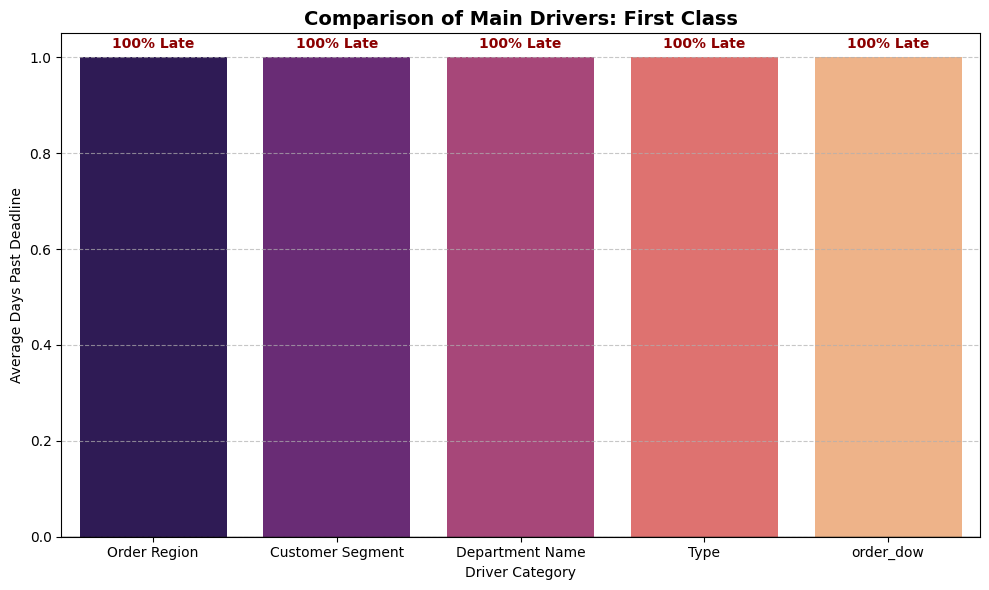

In [33]:

def compare_main_drivers(dataframe, shipping_mode='First Class'):
    # Filter for the bottleneck
    df_mode = dataframe[dataframe['Shipping Mode'] == shipping_mode].copy()

    # The main drivers you want to compare
    main_drivers = ['Order Region', 'Customer Segment', 'Department Name', 'Type', 'order_dow']

    summary_data = []

    for driver in main_drivers:
        # Calculate the average delay for the entire main driver
        avg_delay = df_mode['Delay'].mean()
        avg_late_pct = df_mode['Is_Delayed'].mean() * 100

        summary_data.append({
            'Main Driver': driver,
            'Avg Delay (Days)': avg_delay,
            'Late Delivery %': avg_late_pct
        })

    # Create a simple summary DataFrame
    comparison_df = pd.DataFrame(summary_data).sort_values('Avg Delay (Days)', ascending=False)

    # Visualization
    plt.figure(figsize=(10, 6))

    # Bar plot for Average Delay Days
    sns.barplot(
        data=comparison_df,
        x='Main Driver',
        y='Avg Delay (Days)',
        palette='magma' )

    # Adding a horizontal line to show the "Target" (which is 0 delay)
    plt.axhline(0, color='black', linewidth=1)

    plt.title(f'Comparison of Main Drivers: {shipping_mode}', fontsize=14, fontweight='bold')
    plt.ylabel('Average Days Past Deadline')
    plt.xlabel('Driver Category')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate the bars with the Late %
    for i, row in enumerate(comparison_df.itertuples()):
        plt.text(i, row._2 + 0.02, f'{row._3:.0f}% Late',
                 ha='center', fontweight='bold', color='darkred')

    plt.tight_layout()
    plt.show()

# Run the high-level comparison
compare_main_drivers(df, shipping_mode='First Class')

#### The bottleneck is not **operational**; it is informational. There is a 100% mismatch between the **Scheduled Days** and the **Minimum Processing Capability** of the fulfillment centers.

- **Evidence:** Regardless of the product, payment type, or day of the week, the 'Real' shipping time is a constant **2 days.**

- **The Flaw:** The system is set to expect 'First Class' in **1 day.**

- **The Insight:** The company is setting its employees up for failure by promising a 1-day turnaround that doesn't exist in their physical workflow."

---
### **Time-Based Analysis**

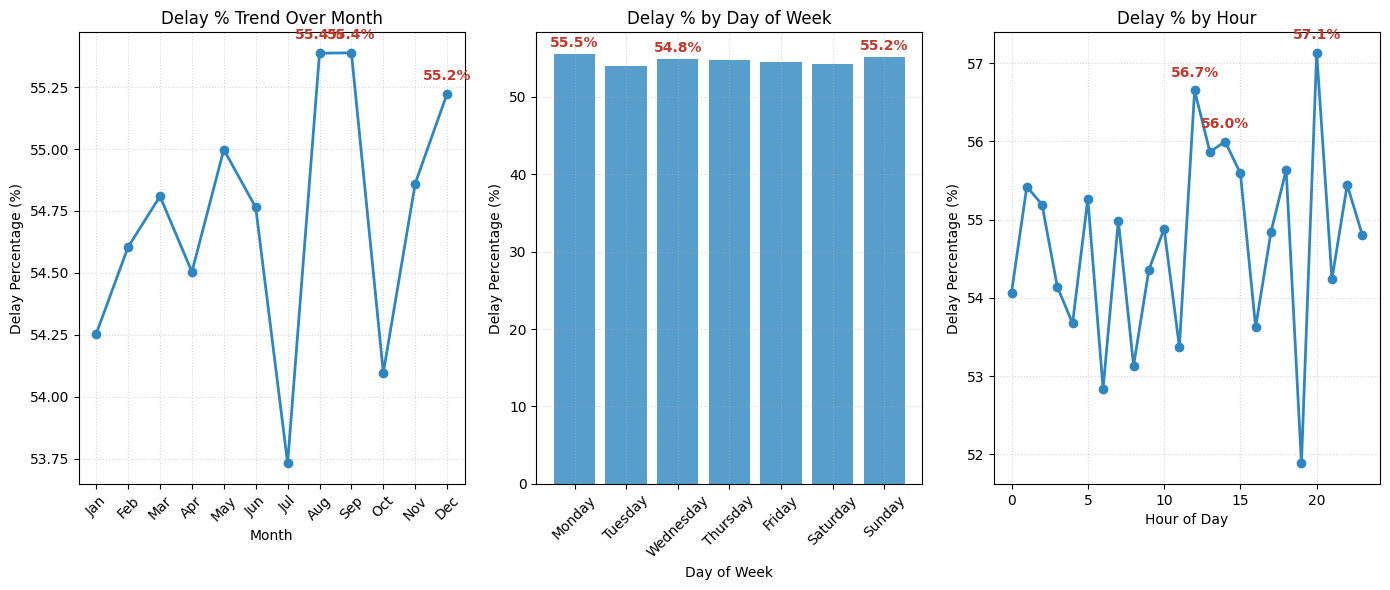

In [34]:

delay_by_month = df.groupby('order_month')['Is_Delayed'].mean().reset_index()
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = df.groupby('Order_day')['Is_Delayed'].mean().reset_index()
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = df.groupby('order_hour')['Is_Delayed'].mean().reset_index()
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

# 2. Setup Figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))
primary_color = '#2E86C1'
danger_color = '#C0392B'

# --- Subplot 1: Delay % Trend Over Month ---
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color, linewidth=2)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate Top 3 Months
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%",
                 (row['order_month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=10, color=danger_color, fontweight='bold')

# --- Subplot 2: Delay % by Day of Week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Ensure your column matches the strings in day_order
delay_by_day['Order_day'] = pd.Categorical(delay_by_day['Order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('Order_day')

ax2.bar(delay_by_day['Order_day'], delay_by_day['delay_pct'], color=primary_color, alpha=0.8)
ax2.set_xticklabels(delay_by_day['Order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate Top 3 Days
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    ax2.text(row['Order_day'], row['delay_pct'] + 0.5, f"{row['delay_pct']:.1f}%",
             ha='center', va='bottom', fontsize=10, color=danger_color, fontweight='bold')

# --- Subplot 3: Delay % by Hour ---
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color, linewidth=2)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate Top 3 Hours
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%",
                 (row['order_hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=10, color=danger_color, fontweight='bold')

plt.tight_layout()
plt.show()

---
### **Machine Learning MOdeling**

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [36]:

# 1. Feature Selection

X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment',
        'Department Name', 'Order Region', 'Shipping Mode', 'order_month', 'order_hour']]
y = df['Late_delivery_risk']


In [37]:

# 2. Frequency Encoding
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical Columns:', cat_cols)

# Frequency encoding low-dimensional and robust for hogh-cardinality
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Drop original text columns, keep only the numbers
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# using encoded features for modeling
X = X_encoded

# 3. Train/Test Split
# We keep 20% of data aside to "test" the model later
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)



Categorical Columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


In [38]:
# 4. Handling Class Imbalance with SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [39]:
# Fit the Random Forest on balanced data

# 1. Define the Evaluation Function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall:", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))



In [40]:
# 2. Fit the Random Forest model on the BALANCED data

rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

# 3. Predict on the original TEST data
y_pred_rf_balanced = rf_model_balanced.predict(X_test)

# 4. Run the evaluation
evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy: 0.74
Precision: 0.79
Recall: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553



### The Random Forest Classifier was used to predict late delivery risks by aggregating the decisions of multiple decision trees to ensure robust and stable predictions. It achieved an accuracy of **74%**, demonstrating a strong ability to identify patterns between shipping modes and scheduling gaps while maintaining a high precision of **79%** for late-risk flagging."

### **Summary and Recommendations**

This analysis addresses the critical business problem of inconsistent delivery performance within a global e-commerce platform, aiming to understand and mitigate late deliveries to improve customer trust and order profitability.

**1. Data Loading and Initial Exploration:**
- The analysis began by loading the `DataCoSupplyChainDataset.csv` and conducting an initial inspection using `df.head()`, `df.info()`, and `df.shape` to understand its structure, identify data types, and check for missing values and duplicates.

**2. Data Cleaning and Preprocessing:**
- Irrelevant and redundant columns (e.g., 'Product Description', 'Customer Email', 'Order Zipcode', 'Benefit per order') were identified and dropped to streamline the dataset.
- Canceled orders were removed as they are not pertinent to delivery time analysis.
- Date columns (`order date (DateOrders)`, `shipping date (DateOrders)`) were converted to datetime objects, handling potential errors.

**3. Feature Engineering:**
- New features were engineered to capture key aspects of delivery:
  - `Order Processing Time`: The duration between order and shipping dates.
  - `Delay`: The difference between `Order Processing Time` and `Days for shipment (scheduled)`.
  - `Is_Delayed`: A boolean flag indicating whether an order was delayed.
  - `order_month`, `Order_day`, `order_hour`: Extracted from the `order date (DateOrders)` for time-based analysis.
  - `Profitability_Flag`: Categorized orders into 'Profit', 'Loss', or 'Break-even' based on 'Order Profit Per Order'.

**4. Exploratory Data Analysis (EDA):**
- **Profitability Distribution:** A pie chart revealed the proportion of profitable, loss-making, and break-even orders.
- **Business KPIs:** Key metrics were calculated and displayed, including total orders, late deliveries count, 90th percentile delay, on-time delivery percentage (45.29%), and late delivery percentage (54.71%). Notably, the analysis quantified significant total profits and total losses due to delays.
- **Profit Metrics by Delay:** A detailed table and a dual-axis plot showed mean and total profit by delay days, indicating how profit is affected by different delay durations.
- **Delay Distribution:** A bar chart illustrated the percentage of orders for each delay day, showing that a significant portion of orders experience 1 or 2 days of delay.

**5. Bottleneck Detection:**
- A function `compute_delay_pct_by_category` was used to calculate the percentage of late orders across various categorical dimensions (`Order Region`, `Customer Segment`, `Shipping Mode`, `Order Status`, `Type`, `Department Name`).
- Visualizations in a 2x3 grid highlighted categories with the highest delay percentages, pinpointing potential operational bottlenecks.

**6. Root Cause Analysis:**
- Focused on `Shipping Mode`, the analysis revealed a critical **informational bottleneck**: a consistent mismatch between the **scheduled days** and the **real shipping days**.
- For 'First Class' shipping, orders scheduled for 1 day consistently took 2 days to ship, indicating a systemic flaw in scheduling that sets employees up for failure.

**7. Time-Based Analysis:**
- Line plots and bar charts visualized the percentage of delays across `order_month`, `Order_day` (day of the week), and `order_hour` (hour of the day), identifying periods with higher likelihood of delays.

**8. Machine Learning Modeling:**
- **Objective:** Predict 'Late_delivery_risk'.
- **Feature Selection:** Selected relevant features including `Type`, `Days for shipment (scheduled)`, `Category Name`, `Customer Segment`, `Department Name`, `Order Region`, `Shipping Mode`, `order_month`, and `order_hour`.
- **Encoding:** Categorical features were transformed using frequency encoding.
- **Train/Test Split:** Data was split into 80% training and 20% testing sets, stratified to maintain the proportion of late deliveries.
- **Class Imbalance Handling:** SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data to balance the classes, addressing the imbalance between late and on-time deliveries.
- **Model Training and Evaluation:**
  - A `RandomForestClassifier` was trained on the balanced training data.
  - The model was evaluated on the original (unbalanced) test data using accuracy, precision, recall, and a classification report.
  - The model achieved an **accuracy of 74%**, with a **precision of 79%** and **recall of 75%** on the test set, demonstrating a strong capability to identify patterns and flag high-risk orders. These metrics suggest a robust model for predicting late deliveries.

**Recommendations:**
1. **Revise Shipping Schedule for 'First Class':** Immediately adjust the 'First Class' shipping schedule to reflect the actual 2-day processing time. This will align expectations with operational reality, reduce late delivery flags, and improve system accuracy.
2. **Investigate High-Delay Bottlenecks:** Focus on the specific regions, customer segments, and order statuses identified as having high delay percentages during the bottleneck detection phase. Implement targeted process improvements for these areas.
3. **Optimize Order Processing:** Analyze the root causes for orders experiencing 1-2 days of delay. There's potential to optimize processes to move these into the 'on-time' category.
4. **Monitor Time-Based Trends:** Use the time-based analysis insights to staff accordingly during peak delay hours or months, or to implement preventative measures during these periods.
5. **Leverage ML Model for Proactive Management:** Integrate the Random Forest model into the order fulfillment system to proactively flag high-risk orders. This allows for early intervention, such as re-routing or expedited handling, to prevent late deliveries.